# PASO 5 — Análisis de Clustering
## Proyecto: Análisis de Churn en TELCO

**Equipo:** Data & BI

**Objetivo de esta fase:** segmentar a los clientes de TELCO en grupos con
características similares para entender los distintos **perfiles de cliente** y
cómo se relacionan con el churn, complementando el análisis predictivo del PASO 4.

A diferencia del modelado predictivo, el clustering es **no supervisado**: no
usamos `churn_value` como variable objetivo durante el entrenamiento — los grupos
emergen exclusivamente de la similitud entre clientes. Una vez asignados los
clusters, sí calculamos la tasa de churn de cada uno para validar que los grupos
tienen sentido de negocio.

El flujo de trabajo es:

1. **Selección de variables** para el clustering.
2. **Preprocesamiento** — pipeline con StandardScaler y OHE.
3. **Método del Codo** — determinar el rango de K óptimos.
4. **Silhouette Score** — validar y comparar con el codo.
5. **Decisión de K** — elegir K con criterio de negocio.
6. **Interpretación de clusters** — perfiles, churn rate, variables clave.
7. **Visualización PCA** en 2D.
8. **Exportar** `telco_clustered.csv`.

Todas las figuras se guardan en `docs/analisis_cluster/`.
**Entregable:** `data/processed/telco_clustered.csv`

## 0. Configuración inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid')

CLEANED_PATH   = '../data/cleaned/telco_cleaned.csv'
PROCESSED_PATH = '../data/processed/'
OUT_DIR        = '../docs/analisis_cluster/'
os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(CLEANED_PATH)
print("Shape:", df.shape)
print(f"Tasa de churn global: {df['churn_value'].mean():.2%}")

Shape: (7043, 48)
Tasa de churn global: 26.54%


## 1. Selección de variables para el clustering

No todas las variables son adecuadas para el clustering. Partimos de las
conclusiones del PASO 3 (Cramér's V y correlación de Pearson) y del PASO 4
(importancia de variables) para seleccionar un subconjunto que capture bien el
**perfil comercial del cliente**.

### Variables escogidas

**Numéricas (8 variables):**

| Variable | Justificación |
|---|---|
| `age` | Perfil demográfico básico. |
| `number_of_dependents` | Estructura familiar — protectora del churn. |
| `number_of_referrals` | Señal de compromiso con el servicio. |
| `tenure_in_months` | Antigüedad — la variable numérica con más correlación con el churn (-0,353). |
| `monthly_charge` | Nivel de gasto mensual — proxy del tier de servicio. |
| `total_charges` | Valor acumulado aportado al negocio. |
| `total_long_distance_charges` | Nivel de uso de larga distancia. |
| `avg_monthly_gb_download` | Intensidad de uso del servicio de internet. |

**Categóricas (9 variables):**

| Variable | Justificación |
|---|---|
| `contract` | La más asociada al churn (Cramér's V = 0,453). |
| `internet_type` | Segunda más asociada (0,305). |
| `offer` | Tercera más asociada (0,262). |
| `payment_method` | Señal de automatización/compromiso financiero (0,219). |
| `married` | Perfil familiar complementario. |
| `online_security` | Servicio add-on — distingue clientes básicos de avanzados. |
| `premium_tech_support` | Lo mismo que `online_security` |
| `paperless_billing` | Perfil digital. |
| `unlimited_data` | Diferencia heavy users de usuarios moderados. |

### Variables descartadas y por qué

| Variable | Motivo del descarte |
|---|---|
| `customer_id`, `city`, `zip_code`, etc. | Identificadores, no descriptivos del perfil. |
| `churn_value`, `customer_status`, `churn_*` | El target y sus derivadas — incluirlas haría que el clustering buscara reproducir el churn, no los perfiles. |
| `antiguedad_anios`, `total_revenue` | Redundantes con `tenure_in_months` y las 4 componentes (ya identificadas en PASO 3). |
| `latitude`, `longitude` | Alta multicolinealidad entre sí, sin señal propia de negocio. |
| `population` | Variable geográfica, no característica del cliente. |
| `gender`, `phone_service`, `streaming_*`, `multiple_lines` | Cramér's V < 0,07 con el churn en el PASO 3, poca capacidad discriminante. |
| `under_30`, `senior_citizen`, `dependents`, `grupo_edad` | Derivadas de `age` y `number_of_dependents` — añaden ruido sin información nueva. |
| `total_refunds`, `total_extra_data_charges` | Casi siempre 0, sin varianza útil. |

In [2]:
# Variables para el clustering
CLUSTER_NUM = [
    'age', 'number_of_dependents', 'number_of_referrals', 'tenure_in_months',
    'monthly_charge', 'total_charges', 'total_long_distance_charges',
    'avg_monthly_gb_download'
]

CLUSTER_CAT = [
    'contract', 'internet_type', 'offer', 'payment_method', 'married',
    'online_security', 'premium_tech_support', 'paperless_billing', 'unlimited_data'
]

CLUSTER_COLS = CLUSTER_NUM + CLUSTER_CAT
X = df[CLUSTER_COLS]

print(f"Variables numéricas ({len(CLUSTER_NUM)}): {CLUSTER_NUM}")
print(f"\nVariables categóricas ({len(CLUSTER_CAT)}): {CLUSTER_CAT}")
print(f"\nTotal variables: {len(CLUSTER_COLS)}")
print(f"Clientes: {len(X)}")

Variables numéricas (8): ['age', 'number_of_dependents', 'number_of_referrals', 'tenure_in_months', 'monthly_charge', 'total_charges', 'total_long_distance_charges', 'avg_monthly_gb_download']

Variables categóricas (9): ['contract', 'internet_type', 'offer', 'payment_method', 'married', 'online_security', 'premium_tech_support', 'paperless_billing', 'unlimited_data']

Total variables: 17
Clientes: 7043


### ¿Por qué es importante escalar las variables numéricas antes de aplicar K-Means?

K-Means mide distancias entre puntos en el espacio de variables. Si no escalamos,
las variables con **mayor rango numérico** dominan completamente el cálculo de
distancias, aunque no sean más importantes:

- `total_charges` puede ir de 18 a 8.673 (rango ≈ 8.655).
- `number_of_dependents` va de 0 a 9 (rango ≈ 9).

Sin escalar, una diferencia de 1 en `total_charges` equivale (matemáticamente)
a 1 en `number_of_dependents`, pero en realidad representan cosas completamente
distintas. K-Means se convirtería en un "clasificador de total_charges" ignorando
casi todo lo demás.

Con **StandardScaler** (media=0, desviación típica=1), todas las variables
numéricas contribuyen en igualdad de condiciones al cálculo de distancias.

## 2. Preprocesamiento para clustering

In [3]:
# Transformador numerico: imputa medianas + StandardScaler
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Transformador categorico: imputa moda + OneHotEncoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer: aplica cada transformer a sus columnas
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,    CLUSTER_NUM),
    ('cat', categorical_transformer, CLUSTER_CAT)
])

# Fit y transform sobre el dataset completo
# (en clustering no hay train/test: usamos todos los clientes)
X_proc = preprocessor.fit_transform(X)

print(f"Shape original:   {X.shape}")
print(f"Shape procesado:  {X_proc.shape}")
print(f"  · {len(CLUSTER_NUM)} variables numéricas (escaladas)")
raw = preprocessor.get_feature_names_out()
clean = [n.replace('num__','').replace('cat__','') for n in raw]
print(f"  · {len(clean)-len(CLUSTER_NUM)} columnas OHE (de {len(CLUSTER_CAT)} variables categóricas)")

Shape original:   (7043, 17)
Shape procesado:  (7043, 34)
  · 8 variables numéricas (escaladas)
  · 26 columnas OHE (de 9 variables categóricas)


## 3. ¿Cuántos clusters elegir? — Método del Codo (Elbow Method)

Entrenamos K-Means para K entre 2 y 10 y representamos la **inercia** (suma de
distancias cuadradas de cada punto al centroide de su cluster) en función de K.
Buscamos el punto donde la reducción de inercia se aplana — el "codo" — que
indica que añadir más clusters no mejora significativamente la compacidad.

In [4]:
K_range  = range(2, 11)
inertias = []
sil_scores = []

print("Calculando K-Means para K = 2..10 ...")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_proc)
    inertias.append(km.inertia_)
    # sample_size acelera el calculo en datasets grandes sin perder representatividad
    s = silhouette_score(X_proc, labels, sample_size=2000, random_state=42)
    sil_scores.append(s)
    print(f"  K={k:2d} | Inercia = {km.inertia_:>10,.0f} | Silhouette = {s:.4f}")

Calculando K-Means para K = 2..10 ...
  K= 2 | Inercia =     72,948 | Silhouette = 0.1908
  K= 3 | Inercia =     63,761 | Silhouette = 0.1735
  K= 4 | Inercia =     59,500 | Silhouette = 0.1594
  K= 5 | Inercia =     56,597 | Silhouette = 0.1385
  K= 6 | Inercia =     53,871 | Silhouette = 0.1430
  K= 7 | Inercia =     51,707 | Silhouette = 0.1336
  K= 8 | Inercia =     49,757 | Silhouette = 0.1251
  K= 9 | Inercia =     48,136 | Silhouette = 0.1197
  K=10 | Inercia =     46,861 | Silhouette = 0.1194


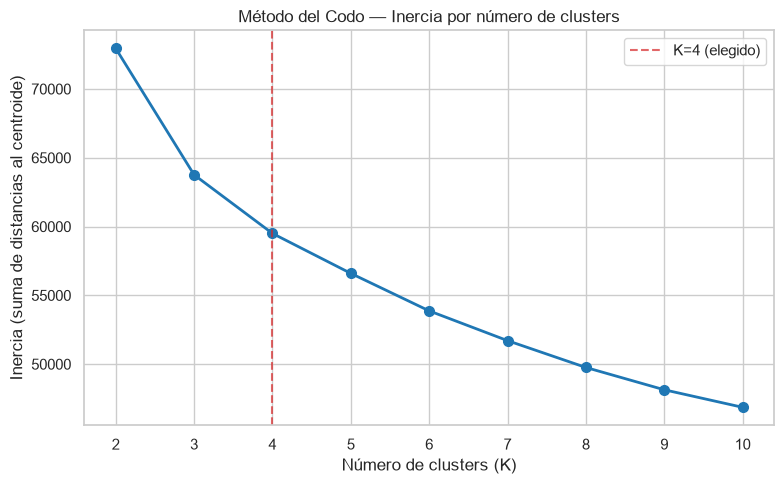

Guardado: visual_elbow.png


In [5]:
# ── Grafico del Codo ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_range), inertias, marker='o', color='#1f77b4', linewidth=2, markersize=7)
ax.axvline(x=4, color='#d62728', linestyle='--', alpha=0.7, label='K=4 (elegido)')
ax.set_xlabel('Número de clusters (K)')
ax.set_ylabel('Inercia (suma de distancias al centroide)')
ax.set_title('Método del Codo — Inercia por número de clusters')
ax.set_xticks(list(K_range))
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'visual_elbow.png', dpi=110, bbox_inches='tight')
plt.show()
print("Guardado: visual_elbow.png")

## 4. Validación con Silhouette Score

El **Silhouette Score** mide qué tan bien está asignado cada punto a su cluster.
Para cada punto combina:

- **Cohesión interna (a)**: distancia media al resto de puntos de su cluster.
- **Separación externa (b)**: distancia media al cluster más cercano.

`Silhouette = (b - a) / max(a, b)`, oscila entre -1 y +1. Valores cercanos a 1
indican clusters bien definidos y separados entre sí. **Mayor es mejor.**

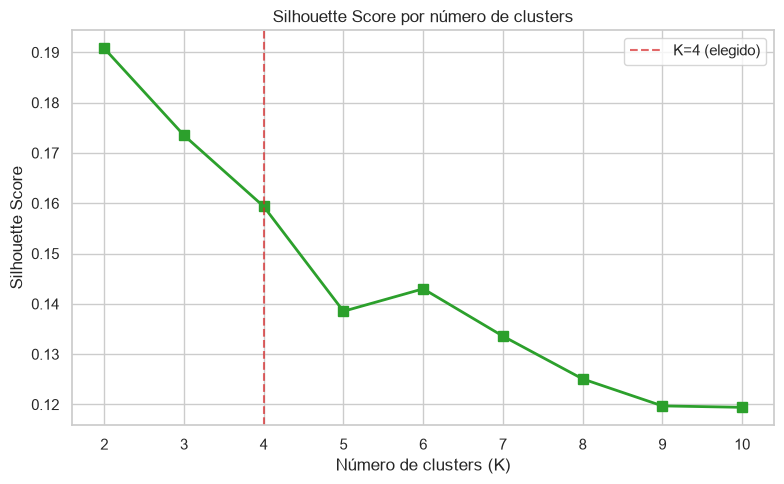

Guardado: silueta_score.png


In [6]:
# ── Grafico Silhouette Score ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_range), sil_scores, marker='s', color='#2ca02c', linewidth=2, markersize=7)
ax.axvline(x=4, color='#d62728', linestyle='--', alpha=0.7, label='K=4 (elegido)')
ax.set_xlabel('Número de clusters (K)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score por número de clusters')
ax.set_xticks(list(K_range))
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'silueta_score.png', dpi=110, bbox_inches='tight')
plt.show()
print("Guardado: silueta_score.png")

**¿El codo y el silhouette coinciden?**

No del todo — y esto es precisamente la "decisión clave" que menciona el documento
de requisitos:

- **El codo** sugiere K=3 o K=4, donde la reducción de inercia empieza a aplanarse
  claramente.
- **El Silhouette Score** tiene su máximo en K=2 (0,191) y decrece monótonamente
  — técnicamente, K=2 produciría los clusters "más puros y separados".

**Pero K=2 no tiene sentido de negocio**: divide a los clientes en solo dos
grandes bloques (básicamente "con internet / sin internet") que no permiten
diseñar estrategias de retención diferenciadas. K=3 mejora algo la interpretabilidad,
pero K=4 es el que produce **cuatro perfiles realmente distintos y accionables**,
como veremos en la siguiente sección.

Esta es precisamente la razón por la que el documento advierte que, cuando el
codo y el silhouette no coinciden, hay que evaluar también la **interpretabilidad
comercial** de los clusters resultantes. En este caso, **elegimos K=4** como
equilibrio entre validación estadística (segundo mejor silhouette, inercia
claramente en zona de codo) y valor de negocio (cuatro segmentos diferenciados).

## 5. Entrenamiento del modelo final — K=4

In [7]:
K_OPTIMO = 4

km_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_proc)

print(f"K-Means entrenado con K={K_OPTIMO}")
print(f"\nDistribución de clientes por cluster:")
for c in range(K_OPTIMO):
    n  = (df['cluster'] == c).sum()
    pct = n / len(df) * 100
    print(f"  Cluster {c}: {n:>5} clientes ({pct:.1f}%)")

K-Means entrenado con K=4

Distribución de clientes por cluster:
  Cluster 0:  2511 clientes (35.7%)
  Cluster 1:  1576 clientes (22.4%)
  Cluster 2:  1906 clientes (27.1%)
  Cluster 3:  1050 clientes (14.9%)


## 6. Interpretación de los clusters

Analizamos el perfil de cada grupo calculando las medias de las variables
numéricas y la distribución de las categóricas más relevantes.

In [8]:
# ── Tabla de medias numericas por cluster ───────────────────────────
print("=== Medias de variables numéricas por cluster ===\n")
num_means = df.groupby('cluster')[CLUSTER_NUM + ['churn_value']].mean().round(2)
num_means.T

=== Medias de variables numéricas por cluster ===



cluster,0,1,2,3
age,55.54,44.00,49.76,29.19
number_of_dependents,0.10,0.75,0.45,0.96
number_of_referrals,0.68,2.20,3.31,2.17
tenure_in_months,16.39,30.76,59.88,23.20
monthly_charge,69.93,21.10,89.44,66.55
total_charges,"1,174.49",696.62,"5,425.82","1,592.48"
total_long_distance_charges,289.40,753.91,"1,551.21",385.20
avg_monthly_gb_download,16.32,0.54,24.55,53.21
churn_value,0.49,0.08,0.13,0.26


In [9]:
# ── Tabla de churn rate y tamaño ────────────────────────────────────
resumen = df.groupby('cluster').agg(
    N          = ('churn_value', 'count'),
    Churn_rate = ('churn_value', 'mean'),
    Pct_total  = ('churn_value', lambda x: len(x)/len(df)*100),
    Tenure_med = ('tenure_in_months', 'mean'),
    Charge_med = ('monthly_charge', 'mean'),
    Age_med    = ('age', 'mean'),
).round(2)
print("=== Resumen por cluster ===\n")
resumen

=== Resumen por cluster ===



,N,Churn_rate,Pct_total,Tenure_med,Charge_med,Age_med
cluster,,,,,,
0,2511,0.49,35.65,16.39,69.93,55.54
1,1576,0.08,22.38,30.76,21.10,44.00
2,1906,0.13,27.06,59.88,89.44,49.76
3,1050,0.26,14.91,23.20,66.55,29.19


In [10]:
# ── Variables categoricas clave por cluster ──────────────────────────
for cat_var in ['contract', 'internet_type', 'offer', 'payment_method']:
    print(f"\n--- {cat_var} (% por cluster) ---")
    tab = df.groupby('cluster')[cat_var].value_counts(normalize=True).mul(100).round(1).unstack().fillna(0)
    print(tab)


--- contract (% por cluster) ---
contract  Month-to-Month  One Year  Two Year
cluster                                     
0                  80.30     11.80      7.90
1                  34.00     24.60     41.40
2                  17.60     33.90     48.50
3                  68.80     21.00     10.30

--- internet_type (% por cluster) ---
internet_type  Cable   DSL  Fiber Optic  No Internet
cluster                                             
0              14.30 28.90        56.60         0.20
1               1.30  1.70         0.40        96.60
2              12.40 24.50        63.10         0.00
3              20.20 41.20        38.60         0.00

--- offer (% por cluster) ---
offer    No Offer  Offer A  Offer B  Offer C  Offer D  Offer E
cluster                                                       
0           57.40     0.20     3.30     7.60    12.90    18.60
1           55.90     5.90    10.90     5.20    10.70    11.40
2           51.00    21.50    25.60     1.90     0.10   

### Denominación comercial de cada cluster

Con los datos anteriores, los cuatro clusters tienen perfiles bien diferenciados
que permiten darles **nombres comerciales accionables**:

---

#### 🔴 Cluster 0 — "Alto Riesgo: Digitales Nuevos" (35,7% de clientes, **churn 48,6%**)

El grupo con mayor tasa de churn con diferencia. Perfil: clientes **relativamente
jóvenes** (media 55 años, aunque concentra a los más "digitalmente activos"),
**poca antigüedad** (≈16 meses), mayoritariamente con **contrato mes-a-mes**
(80%) y **Fiber Optic** (57%). Apenas tienen dependientes (media 0,10), escasa
seguridad online (79% sin ella), pagan principalmente por domiciliación bancaria
y su oferta predominante incluye las más asociadas al churn (Offer E/D con 31%).
San Diego está muy sobrerrepresentado aquí (145 de 285 clientes de SD).

**Estrategia de retención:** incentivar la migración a contrato anual, ofrecer
descuentos en seguridad online, revisar la oferta E en esta zona.

---

#### 🟢 Cluster 1 — "Básicos Estables: Sin Internet" (22,4% de clientes, **churn 7,8%**)

El cluster con **menor tasa de churn** de todos. Clientes con un perfil de gasto
muy bajo (`monthly_charge` medio ≈21 €) y que en el **96,6% de los casos no
tienen servicio de internet** — son clientes de voz/telefonía básica. Su
antigüedad media es moderada (31 meses), tienen más estructura familiar (47%
casados, media de 0,75 dependientes) y pagan predominantemente con tarjeta de
crédito (61%). La mayoría tiene contratos más comprometidos (41% Two Year).

**Estrategia:** este grupo es estable — el objetivo no es retenerlos, sino
**hacerles upselling** de servicios de internet.

---

#### 🔵 Cluster 2 — "Clientes Fieles Premium" (27,1% de clientes, **churn 13,1%**)

El cluster de clientes **más valiosos y más fidelizados**. Antigüedad media de
casi 5 años (60 meses), contrato Two Year predominante (49%), `monthly_charge`
más alto de todos (≈89 €), total acumulado muy alto (≈5.426 €). Predomina Fiber
Optic (63%) con buenos add-ons (58% con seguridad online). Son mayoritariamente
casados (74%) y tienen buen historial de referidos (3,3 de media).

**Estrategia:** este grupo genera el mayor revenue. El objetivo es mantenerlos
satisfechos (soporte premium, ofertas de fidelización) y aprovechar su
disposición a referir.

---

#### 🟡 Cluster 3 — "Vulnerables Jóvenes con Familia" (14,9% de clientes, **churn 26,4%**)

Un segmento de clientes **jóvenes** (media de edad 29 años), con la mayor
proporción de dependientes (0,96 de media), poca antigüedad (23 meses) y un mix
de contratos (69% mes-a-mes). Destacan por su altísimo uso de datos
(`avg_monthly_gb_download` ≈53 GB, el más alto), lo que sugiere que son
**heavy users de streaming/datos**, probablemente en un contexto familiar. Son
el cluster con mayor presencia de clientes de DSL (41%).

**Estrategia:** ofrecerles planes familiares con datos ilimitados y contratos a
largo plazo con ventajas económicas para familias.

## 7. Visualizaciones

In [11]:
# ── Paleta y etiquetas de cluster ───────────────────────────────────
CLUSTER_COLORS = {
    0: '#d62728',  # rojo  - Alto Riesgo
    1: '#2ca02c',  # verde - Basicos Estables
    2: '#1f77b4',  # azul  - Fieles Premium
    3: '#ff7f0e',  # naranja - Vulnerables Jovenes
}
CLUSTER_LABELS = {
    0: 'C0: Alto Riesgo\n(Digitales Nuevos)',
    1: 'C1: Básicos Estables\n(Sin Internet)',
    2: 'C2: Fieles Premium\n(Larga Antigüedad)',
    3: 'C3: Vulnerables Jóvenes\n(Familias Activas)',
}
df['cluster_label'] = df['cluster'].map(CLUSTER_LABELS)
print("Etiquetas asignadas.")

Etiquetas asignadas.


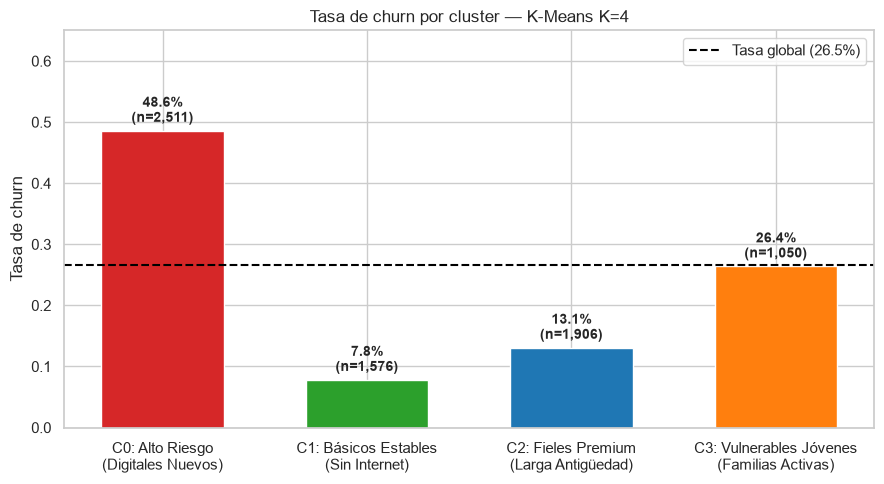

Guardado: churn_por_cluster.png


In [19]:
# ── 1. Churn por cluster ────────────────────────────────────────────
global_churn = df['churn_value'].mean()

churn_cluster = df.groupby('cluster').agg(
    churn_rate = ('churn_value', 'mean'),
    n          = ('churn_value', 'count')
).reset_index()
churn_cluster['color'] = churn_cluster['cluster'].map(CLUSTER_COLORS)
churn_cluster['label'] = churn_cluster['cluster'].map(CLUSTER_LABELS)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(churn_cluster['label'], churn_cluster['churn_rate'],
              color=churn_cluster['color'], edgecolor='white', width=0.6)
ax.axhline(global_churn, color='black', linestyle='--', lw=1.5,
           label=f'Tasa global ({global_churn:.1%})')

for bar, (_, row) in zip(bars, churn_cluster.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f"{row['churn_rate']:.1%}\n(n={row['n']:,})",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0, 0.65)
ax.set_ylabel('Tasa de churn')
ax.set_title('Tasa de churn por cluster — K-Means K=4')
ax.set_xlabel('')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'churn_por_cluster.png', dpi=110, bbox_inches='tight')
plt.show()
print("Guardado: churn_por_cluster.png")

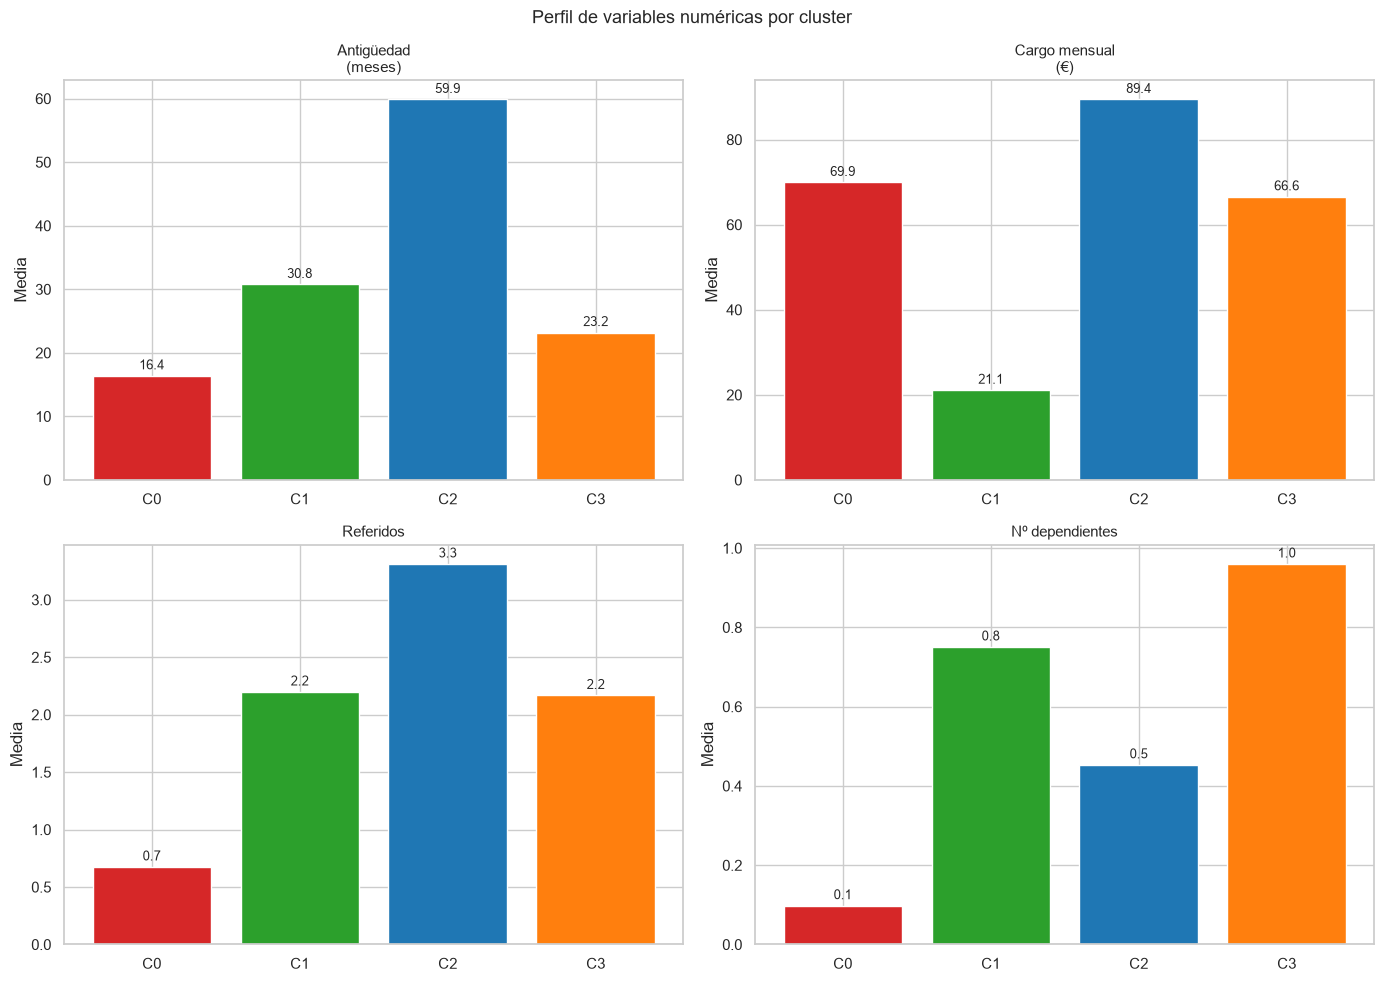

In [13]:
# ── 2. Perfil de variables clave por cluster (radar-like barras) ────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flat

vars_perfil = {
    'Antigüedad\n(meses)': 'tenure_in_months',
    'Cargo mensual\n(€)':   'monthly_charge',
    'Referidos':            'number_of_referrals',
    'Nº dependientes':     'number_of_dependents',
    'GB descarga/mes':     'avg_monthly_gb_download',
    'Cargos larga\ndistancia': 'total_long_distance_charges',
}

medias = df.groupby('cluster')[list(vars_perfil.values())].mean()
etiquetas = [CLUSTER_LABELS[c].replace('\n', ' ') for c in range(4)]

for ax, (label_v, col) in zip(axes, vars_perfil.items()):
    vals = [medias.loc[c, col] for c in range(4)]
    bars = ax.bar(range(4), vals, color=[CLUSTER_COLORS[c] for c in range(4)],
                  edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{v:.1f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(label_v, fontsize=11)
    ax.set_xticks(range(4))
    ax.set_xticklabels([f'C{c}' for c in range(4)])
    ax.set_ylabel('Media')

fig.suptitle('Perfil de variables numéricas por cluster', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR + 'perfil_numerico_clusters.png', dpi=110, bbox_inches='tight')
plt.show()

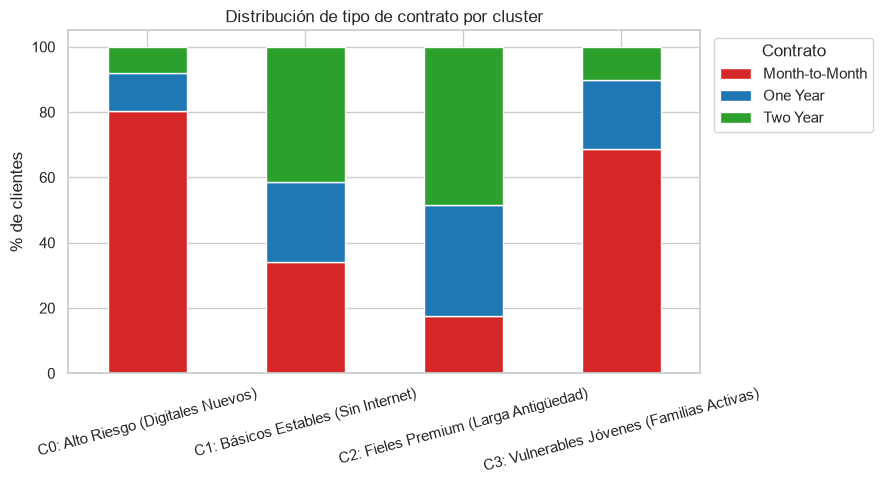

In [14]:
# ── 3. Distribucion de contrato por cluster ─────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
contract_pct = df.groupby(['cluster','contract']).size().unstack(fill_value=0)
contract_pct = contract_pct.div(contract_pct.sum(axis=1), axis=0) * 100
contract_pct.index = [CLUSTER_LABELS[c].replace('\n',' ') for c in contract_pct.index]
contract_pct.plot(kind='bar', stacked=True, ax=ax,
                  color=['#d62728','#1f77b4','#2ca02c'])
ax.set_title('Distribución de tipo de contrato por cluster')
ax.set_ylabel('% de clientes')
ax.set_xlabel('')
ax.legend(title='Contrato', bbox_to_anchor=(1.01, 1))
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(OUT_DIR + 'contrato_por_cluster.png', dpi=110, bbox_inches='tight')
plt.show()

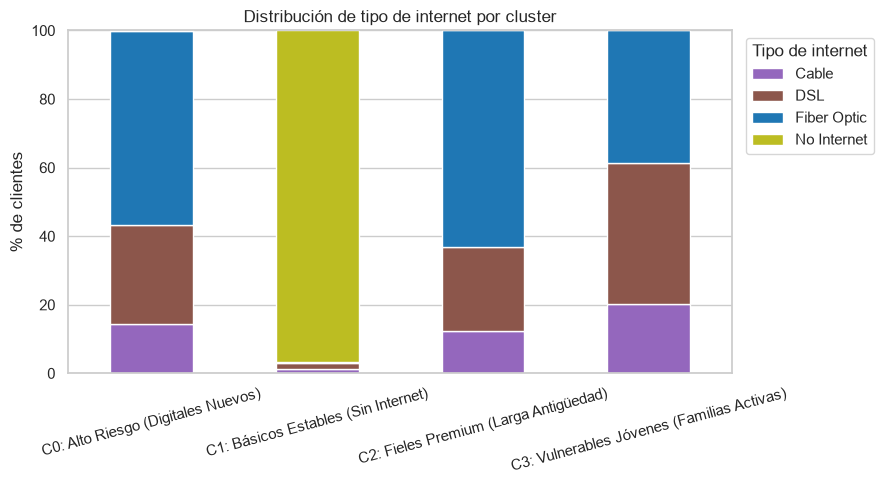

In [15]:
# ── 4. Distribucion de internet type por cluster ────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
it_pct = df.groupby(['cluster','internet_type']).size().unstack(fill_value=0)
it_pct = it_pct.div(it_pct.sum(axis=1), axis=0) * 100
it_pct.index = [CLUSTER_LABELS[c].replace('\n',' ') for c in it_pct.index]
it_pct.plot(kind='bar', stacked=True, ax=ax,
            color=['#9467bd','#8c564b','#1f77b4','#bcbd22'])
ax.set_title('Distribución de tipo de internet por cluster')
ax.set_ylabel('% de clientes')
ax.set_xlabel('')
ax.legend(title='Tipo de internet', bbox_to_anchor=(1.01, 1))
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(OUT_DIR + 'internet_type_por_cluster.png', dpi=110, bbox_inches='tight')
plt.show()

## 8. Visualización con PCA

Aplicamos **PCA (Análisis de Componentes Principales)** para comprimir todas las
dimensiones del espacio preprocesado (34 columnas) en **2 componentes
principales**, y representar cada cliente como un punto coloreado por cluster
en un plano 2D.

Esta visualización no añade información nueva al clustering — los clusters ya
están asignados — pero permite comprobar **visualmente si los grupos están bien
separados** en el espacio de datos.

**Nota importante:** el PCA muestra la "fotografía" del espacio de datos en 2D,
pero el clustering operó en 34 dimensiones. Es normal que los clusters se
solapen ligeramente en 2D: hay información en las otras 32 dimensiones que
el PCA no puede mostrar en una sola figura.

In [16]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_proc)

pca_df = pd.DataFrame({
    'PCA1':    X_pca[:, 0],
    'PCA2':    X_pca[:, 1],
    'cluster': df['cluster'],
    'churn':   df['churn_value'],
})

var_exp = pca.explained_variance_ratio_
print(f"Varianza explicada por PCA1: {var_exp[0]:.2%}")
print(f"Varianza explicada por PCA2: {var_exp[1]:.2%}")
print(f"Total varianza explicada:    {sum(var_exp):.2%}")

Varianza explicada por PCA1: 26.03%
Varianza explicada por PCA2: 15.04%
Total varianza explicada:    41.07%


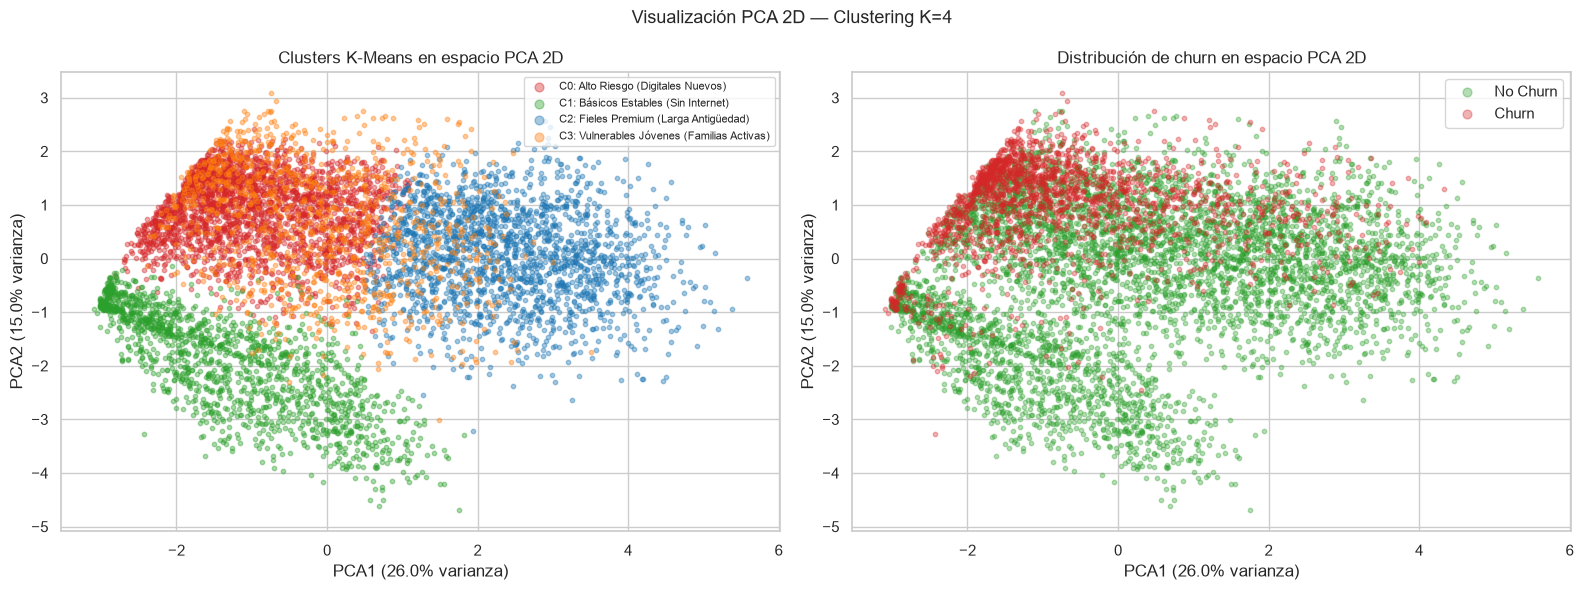

Guardado: pca_clusters.png


In [17]:
# ── Scatter PCA coloreado por cluster ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo: por cluster
for c in range(K_OPTIMO):
    mask = pca_df['cluster'] == c
    axes[0].scatter(pca_df.loc[mask, 'PCA1'],
                    pca_df.loc[mask, 'PCA2'],
                    c=CLUSTER_COLORS[c], alpha=0.4, s=10,
                    label=CLUSTER_LABELS[c].replace('\n',' '))
axes[0].set_xlabel(f'PCA1 ({var_exp[0]:.1%} varianza)')
axes[0].set_ylabel(f'PCA2 ({var_exp[1]:.1%} varianza)')
axes[0].set_title('Clusters K-Means en espacio PCA 2D')
axes[0].legend(loc='upper right', fontsize=8, markerscale=2)

# Panel derecho: por churn_value
churn_colors = {0: '#2ca02c', 1: '#d62728'}
churn_labels = {0: 'No Churn', 1: 'Churn'}
for c_val in [0, 1]:
    mask = pca_df['churn'] == c_val
    axes[1].scatter(pca_df.loc[mask, 'PCA1'],
                    pca_df.loc[mask, 'PCA2'],
                    c=churn_colors[c_val], alpha=0.35, s=10,
                    label=churn_labels[c_val])
axes[1].set_xlabel(f'PCA1 ({var_exp[0]:.1%} varianza)')
axes[1].set_ylabel(f'PCA2 ({var_exp[1]:.1%} varianza)')
axes[1].set_title('Distribución de churn en espacio PCA 2D')
axes[1].legend(markerscale=2)

fig.suptitle('Visualización PCA 2D — Clustering K=4', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR + 'pca_clusters.png', dpi=110, bbox_inches='tight')
plt.show()
print("Guardado: pca_clusters.png")

**Lectura del PCA:**

El panel izquierdo muestra que los 4 clusters tienen cierta separación en el
espacio 2D, aunque con solapamiento — esperable dado que solo visualizamos
el ~20% de la varianza total (el clustering operó en 34 dimensiones). El
Cluster 1 (verde, básicos sin internet) tiende a concentrarse en una zona
diferente del espacio porque su perfil es muy distinto al resto (sin internet,
bajo gasto). Los clusters 0, 2 y 3 se solapan más porque todos tienen internet
y estructuras similares en muchas variables.

El panel derecho confirma visualmente lo que ya sabíamos: los churners (rojo)
se concentran más en la zona del espacio donde predomina el Cluster 0.

## 9. Entregable — exportar `telco_clustered.csv`

Exportamos el dataset completo con la columna de cluster asignada y la etiqueta
comercial. Este archivo, junto con `test_predictions.csv` y `telco_cleaned.csv`,
será cargado en Power BI (PASO 6) para construir el dashboard de segmentación.

In [18]:
CLUSTER_NAME_MAP = {
    0: 'Alto Riesgo: Digitales Nuevos',
    1: 'Basicos Estables: Sin Internet',
    2: 'Fieles Premium: Larga Antiguedad',
    3: 'Vulnerables Jovenes: Familias Activas'
}

df['cluster_name'] = df['cluster'].map(CLUSTER_NAME_MAP)

output_path = PROCESSED_PATH + 'telco_clustered.csv'
df.to_csv(output_path, index=False)

# Verificacion
check = pd.read_csv(output_path)
print(f"Exportado: {output_path}")
print(f"Shape: {check.shape[0]} filas x {check.shape[1]} columnas")
print(f"Nulos: {check.isnull().sum().sum()}")
print(f"\nDistribucion de clusters en el CSV:")
print(check[['cluster','cluster_name']].value_counts().sort_index())

Exportado: ../data/processed/telco_clustered.csv
Shape: 7043 filas x 51 columnas
Nulos: 0

Distribucion de clusters en el CSV:
cluster  cluster_name                         
0        Alto Riesgo: Digitales Nuevos            2511
1        Basicos Estables: Sin Internet           1576
2        Fieles Premium: Larga Antiguedad         1906
3        Vulnerables Jovenes: Familias Activas    1050
Name: count, dtype: int64


## Preguntas de reflexión — Clustering

### 1. ¿Qué número de clusters elegiste y con qué criterios? ¿El codo y la silueta coincidían?

Elegimos **K=4**. El codo y el silhouette **no coincidían exactamente**:

- El **Silhouette Score** tiene su máximo técnico en K=2 (0,191) y decrece
  de forma casi monótona hasta K=10.
- El **método del codo** sugiere que la reducción de inercia se aplana
  claramente entre K=3 y K=4 — K=4 es el punto donde añadir un cluster más
  empieza a tener rendimiento decreciente.

La decisión final fue **K=4 por criterio de negocio**: K=2 solo separa "clientes
con internet" de "clientes sin internet" — un insight trivial que no permite
diseñar estrategias diferenciadas. K=3 mejora algo, pero mezcla en un mismo
cluster a clientes jóvenes con familia (Cluster 3) con perfiles más mayores,
perdiendo un segmento comercialmente relevante. K=4 produce **cuatro perfiles
claramente distintos y accionables**, con tasas de churn muy dispares (7,8% –
48,6%) y características interpretables por el equipo comercial.

### 2. Describe con tus propias palabras el perfil de cada cluster. ¿Son tan diferentes entre sí que podrías ponerle un nombre comercial a cada segmento?

Sí, la verdad es que los perfiles están tan marcados que se diferencian perfectamente. Aquí tienes la propuesta comercial para cada uno:

- **Cluster 0 — "Digitales Nuevos (Alto Riesgo)":** Es el grupo más preocupante. Llevan poco tiempo como clientes (unos 16 meses), tiran de fibra óptica y casi todos (el 80%) están con contrato mes a mes. Al no tener familiares asociados ni haber recomendado a nadie, no tienen nada que los ate a la compañía. Dejan bastante dinero (unos 70 €/mes) pero se dan de baja a la mínima: tienen un churn brutal del 48,6%.

- **Cluster 1 — "Básicos Estables (Solo Voz)":** Son los clientes más tranquilos. Básicamente solo usan la línea de teléfono tradicional (el 97% no tiene internet). Tienen un perfil más familiar, pagan poquito (unos 21 €/mes) y dan muy pocos dolores de cabeza, con un churn bajísimo del 7,8%.

- **Cluster 2 — "Premium Fieles (Larga Antigüedad)":** La joya de la corona. Llevan en la empresa unos 5 años de media, son los que más pagan a fin de mes (sobre 89 €) y, lógicamente, los que más ingresos totales han generado (unos 5.426 €). Están súper fidelizados (solo un 13,1% de churn) y encima actúan como embajadores, trayendo a más de 3 conocidos de media.

- **Cluster 3 — "Jóvenes Vulnerables (Familias Activas)":** Es el segmento más joven (29 años de media). Tienen personas a su cargo y consumen muchísimos datos (unos 53 GB/mes). Tienen un churn moderado-alto (26,4%), lo que indica que seguramente miren mucho el euro y salten si encuentran a la competencia ofreciendo planes familiares más ajustados a su bolsillo.

### 3. ¿Qué clusters tienen mayor tasa de churn? ¿Qué características los definen?

**Cluster 0** con el 48,6% de churn es el más crítico, y sus características
definitivas son: contrato mes-a-mes (80%), Fiber Optic (57%), poca antigüedad
(16 meses), sin dependientes (0,10 de media) y escasa seguridad online (79%
sin ella). Es el perfil de cliente con menor "coste de salida" — sin contrato
que lo retenga, sin familia que dependa del servicio, con alternativas de fibra
disponibles (la competencia es la principal causa de churn según el PASO 1).

**Cluster 3** con el 26,4% también está por encima de la media global (26,5%),
aunque solo ligeramente. Su riesgo viene de la **juventud y poca antigüedad**
(23 meses), combinados con una proporción alta de contratos mes-a-mes (69%).

### 4. ¿Confirman los clusters las hipótesis de Sebastián?

**Hipótesis 1 (contratos mes-a-mes = principal causa del churn):** **confirmada
y reforzada**. El Cluster 0, que tiene el 80% de clientes con contrato
mes-a-mes, es exactamente el cluster con mayor churn (48,6%). La correlación
entre tipo de contrato y churn se refleja perfectamente en la segmentación:
los dos clusters con más MtM (C0: 80%, C3: 69%) son los de mayor churn, y
los dos con más contratos largos (C2: 49% Two Year, C1: 41% Two Year) son los
de menor churn.

**Hipótesis 2 (San Diego = región más afectada):** **confirmada y localizada**.
San Diego tiene 285 clientes, de los cuales **145 (51%) están en el Cluster 0**
(el de mayor churn), frente al 36% del resto de California. Dentro de San Diego,
la tasa de churn del Cluster 0 llega al 83,4% — casi el doble que la media del
cluster en el resto del estado.

### 5. ¿Cómo usarías esta segmentación para diseñar una estrategia de retención diferenciada por perfil de cliente?

| Cluster | Estrategia recomendada |
|---|---|
| **C0 (Alto Riesgo)** | Acción inmediata: llamada proactiva en el mes 3-6 (antes de que se consolide la insatisfacción). Ofrecer migración a contrato anual con descuento + seguridad online gratuita 6 meses. Investigar la situación en San Diego (¿competidor local específico?). |
| **C1 (Básicos Estables)** | No intervenir para retención — ya están fidelizados. Foco en **upselling**: ofrecerles planes de internet básico DSL con precio de entrada atractivo. |
| **C2 (Fieles Premium)** | Programa de fidelización VIP: acceso anticipado a nuevos servicios, descuento por 5 años de antigüedad, incentivos para mantener el número de referidos. Son los mejores embajadores de marca. |
| **C3 (Vulnerables Jóvenes)** | Planes familiares: datos ilimitados con precio por hogar, descuento por domiciliación, incentivo por cambio a contrato bianual. Conectar el servicio con las necesidades del hogar (streaming, teletrabajo, educación online). |

### 6. ¿Qué limitaciones tiene K-Means para este tipo de análisis? ¿Conoces alguna alternativa?

**Limitaciones de K-Means:**

- **Asume clusters esféricos y de tamaño similar**: si los grupos reales tienen
  formas irregulares o tamaños muy dispares, K-Means puede no capturarlos bien.
- **Sensible a outliers**: los centroides se calculan como medias, por lo que
  valores extremos (como los 109 clientes con `age > 100` detectados en el PASO 1)
  pueden desplazarlos.
- **Hay que especificar K de antemano**: no detecta el número de grupos
  automáticamente — de ahí la necesidad del codo/silhouette.
- **Resultados diferentes con distintas inicializaciones**: mitigado con
  `n_init=10` (repite 10 veces con inicializaciones aleatorias distintas y
  elige la mejor).
- **No maneja bien variables categóricas directamente**: por eso necesitamos
  OHE, que puede generar un espacio de alta dimensionalidad donde la distancia
  euclídea pierde parte de su interpretabilidad (maldición de la
  dimensionalidad).

**Alternativas:**

- **DBSCAN**: detecta clusters de forma arbitraria y outliers automáticamente,
  sin necesitar especificar K. Útil cuando los grupos no son esféricos.
- **Gaussian Mixture Models (GMM)**: asignación "suave" (probabilística) a los
  clusters, más flexible que K-Means.
- **K-Modes / K-Prototypes**: versiones de K-Means diseñadas específicamente
  para datos categóricos o mixtos (sin necesitar OHE).
- **Clustering jerárquico aglomerativo**: genera un dendrograma que permite
  explorar distintos niveles de granularidad sin elegir K de antemano.